In [11]:
import torch
import torch.nn as nn
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader , TensorDataset


In [12]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


cuda
25
(960, 1280)
RGB


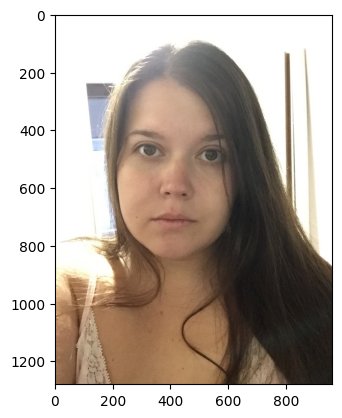

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
import os
from PIL import Image
import matplotlib.pyplot as plt

path = "/content/drive/MyDrive/datasets/21-30"

print(len(os.listdir(path)))

img_name = os.listdir(path)[0]

img = Image.open(os.path.join(path, img_name))

print(img.size)
print(img.mode)

plt.imshow(img)
plt.show()

In [14]:
transform = transforms.Compose([ transforms.Resize((32,32)), 
                                transforms.ToTensor(), 
                                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])

from torch.utils.data import Dataset
from PIL import Image
import os

class FaceDataset(Dataset):

    def __init__(self, path, transform=None):
        self.path = path
        self.transform = transform

        self.images = [
            f for f in os.listdir(path)
            if f.endswith(('.jpg', '.png', '.jpeg'))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(
            self.path,
            self.images[idx]
        )

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img
    
dataset = FaceDataset(
    path,
    transform=transform
)

from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class VQVAE(nn.Module):
    def __init__(self, embedding_dim=64, num_embeddings=32, commitment_cost=0.5):
        super().__init__()

        # ── Encoder ──────────────────────────────
        self.encoder1 = nn.Conv2d(3,  8,  kernel_size=4, stride=2, padding=1)
        self.bn1      = nn.BatchNorm2d(8)
        self.encoder2 = nn.Conv2d(8,  16, kernel_size=4, stride=2, padding=1)
        self.bn2      = nn.BatchNorm2d(16)
        self.encoder3 = nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1)
        self.bn3      = nn.BatchNorm2d(32)
        # Final shape after encoder: [B, 32, 4, 4]  (for 32×32 input)

        # encoder output → embedding_dim (D)
        # If embedding_dim == 64 this is a no-op, but keeps the API clean
        self.pre_vq = nn.Conv2d(32, embedding_dim, kernel_size=1)
        
        # ── Vector Quantizer ──────────────────────────────────────────────────
        self.K    = num_embeddings
        self.D    = embedding_dim
        self.beta = commitment_cost

        self.codebook = nn.Embedding(self.K, self.D)
        nn.init.uniform_(self.codebook.weight, -1 / self.K, 1 / self.K)
        
        # ── Decoder (mirrors the encoder) ────────────────────────────────────
        self.post_vq = nn.Conv2d(embedding_dim, 32, kernel_size=1)
        
        self.decoder3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(inplace=True)
        )
        self.decoder2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8), nn.ReLU(inplace=True)
        )
        self.decoder1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(8, 3, kernel_size=3, padding=1),
        )
        # Output shape: [B, 3, 32, 32]  — matches input
        
        # ── Encoder forward ───────────────────────────────────────────────────────
    def encode(self, x):
        x = F.relu(self.bn1(self.encoder1(x)))
        x = F.relu(self.bn2(self.encoder2(x)))
        x = F.relu(self.bn3(self.encoder3(x)))
        return self.pre_vq(x)          # z_e: (B, D, H', W')

    # ── Vector Quantizer forward ──────────────────────────────────────────────
    def quantize(self, z):
        B, D, H, W = z.shape

        # Flatten spatial dims: (B, D, H, W) → (B*H*W, D)
        z_flat = z.permute(0, 2, 3, 1).contiguous().view(-1, D)

        # Pairwise squared L2: ‖z_e - e_k‖² for all k
        dists = (
            z_flat.pow(2).sum(1, keepdim=True)        # (N, 1)
            + self.codebook.weight.pow(2).sum(1)      # (K,)
            - 2 * z_flat @ self.codebook.weight.t()   # (N, K)
        )

        indices  = dists.argmin(dim=1)                # (N,) nearest entry
        z_q_flat = self.codebook(indices)              # (N, D)
        z_q      = z_q_flat.view(B, H, W, D).permute(0, 3, 1, 2).contiguous()

        # Losses
        codebook_loss   = F.mse_loss(z_q, z.detach())   # ← codebook moves to z_e
        commitment_loss = F.mse_loss(z, z_q.detach())   # ← z_e moves to codebook
        vq_loss = codebook_loss + self.beta * commitment_loss

        # Straight-through estimator: copy z_q value, but pass z_e gradient
        z_q_st = z + (z_q - z).detach()

        return z_q_st, vq_loss, indices.view(B, H, W)

    # ── Decoder forward ───────────────────────────────────────────────────────
    def decode(self, z_q):
        x = self.post_vq(z_q)
        x = F.relu((self.decoder3(x)))
        x = F.relu((self.decoder2(x)))
        return torch.tanh(self.decoder1(x))
    
     # ── Full forward ──────────────────────────────────────────────────────────
    def forward(self, x):
        z_e              = self.encode(x)
        z_q, vq_loss, _  = self.quantize(z_e)
        x_recon          = self.decode(z_q)
        return x_recon, vq_loss
    



In [16]:
model=VQVAE().to(device)
lr=3e-4
optimizer=torch.optim.Adam(model.parameters() , lr=lr)


In [17]:
epochs = 100
beta = 0.1

for epoch in range(epochs):

    total_loss = 0

    for x in loader:

       
        x=x.to(device)
        

        x_recon, vq_loss = model(x)
        
        recon_loss = F.mse_loss(x_recon, x)
        
        loss = recon_loss + beta* vq_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"\nEpoch {epoch+1}")
    print(f"Total Loss: {total_loss:.2f}")
    print(f"Recon Loss: {recon_loss.item():.2f}")
    print(f"VQ Loss: {vq_loss.item():.2f}")
    


Epoch 1
Total Loss: 0.38
Recon Loss: 0.35
VQ Loss: 0.27

Epoch 2
Total Loss: 0.36
Recon Loss: 0.33
VQ Loss: 0.27

Epoch 3
Total Loss: 0.35
Recon Loss: 0.32
VQ Loss: 0.27

Epoch 4
Total Loss: 0.34
Recon Loss: 0.31
VQ Loss: 0.27

Epoch 5
Total Loss: 0.33
Recon Loss: 0.30
VQ Loss: 0.27

Epoch 6
Total Loss: 0.32
Recon Loss: 0.29
VQ Loss: 0.27

Epoch 7
Total Loss: 0.31
Recon Loss: 0.28
VQ Loss: 0.27

Epoch 8
Total Loss: 0.30
Recon Loss: 0.28
VQ Loss: 0.27

Epoch 9
Total Loss: 0.30
Recon Loss: 0.27
VQ Loss: 0.28

Epoch 10
Total Loss: 0.29
Recon Loss: 0.27
VQ Loss: 0.28

Epoch 11
Total Loss: 0.29
Recon Loss: 0.26
VQ Loss: 0.28

Epoch 12
Total Loss: 0.28
Recon Loss: 0.26
VQ Loss: 0.28

Epoch 13
Total Loss: 0.28
Recon Loss: 0.25
VQ Loss: 0.28

Epoch 14
Total Loss: 0.28
Recon Loss: 0.25
VQ Loss: 0.29

Epoch 15
Total Loss: 0.27
Recon Loss: 0.25
VQ Loss: 0.29

Epoch 16
Total Loss: 0.27
Recon Loss: 0.24
VQ Loss: 0.29

Epoch 17
Total Loss: 0.27
Recon Loss: 0.24
VQ Loss: 0.30

Epoch 18
Total Loss: 0

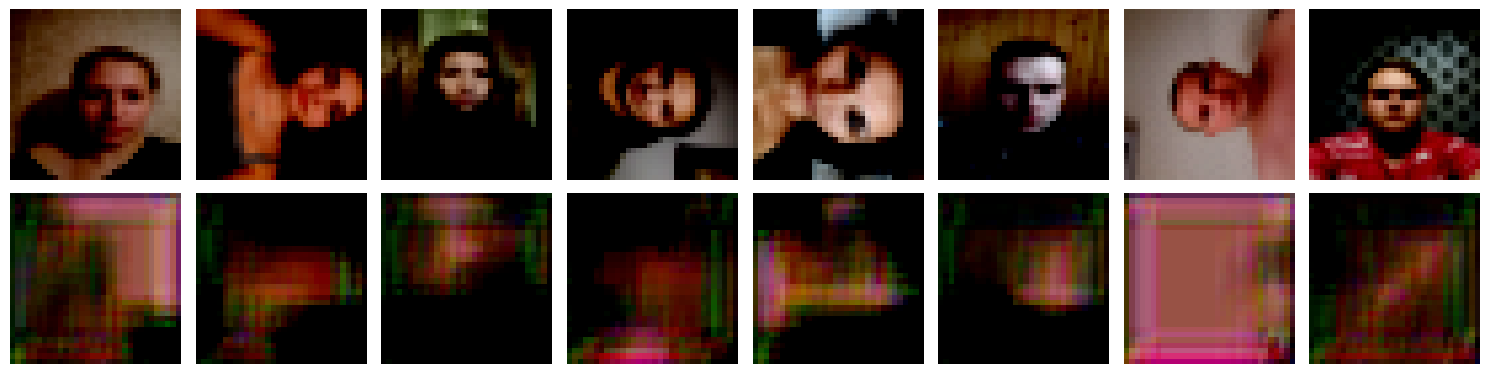

In [18]:
model.eval()

with torch.no_grad():

    # get one batch
    x = next(iter(loader))

    x = x.to(device)

    # forward pass
    x_hat,_ = model(x)

    # move to cpu
    x = x.cpu()
    x_hat = x_hat.cpu()

    # if using sigmoid output:
    # x_hat already in [0,1]

    # if NOT using sigmoid:
    # uncomment below
    # x_hat = torch.sigmoid(x_hat)

# ======================================
# VISUALIZATION
# ======================================

fig, axes = plt.subplots(2, 8, figsize=(15, 4))

for i in range(8):

    # ORIGINAL
    axes[0, i].imshow(
        x[i].permute(1, 2, 0)
    )

    axes[0, i].axis('off')

    # RECONSTRUCTION
    axes[1, i].imshow(
        x_hat[i].permute(1, 2, 0)
    )

    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

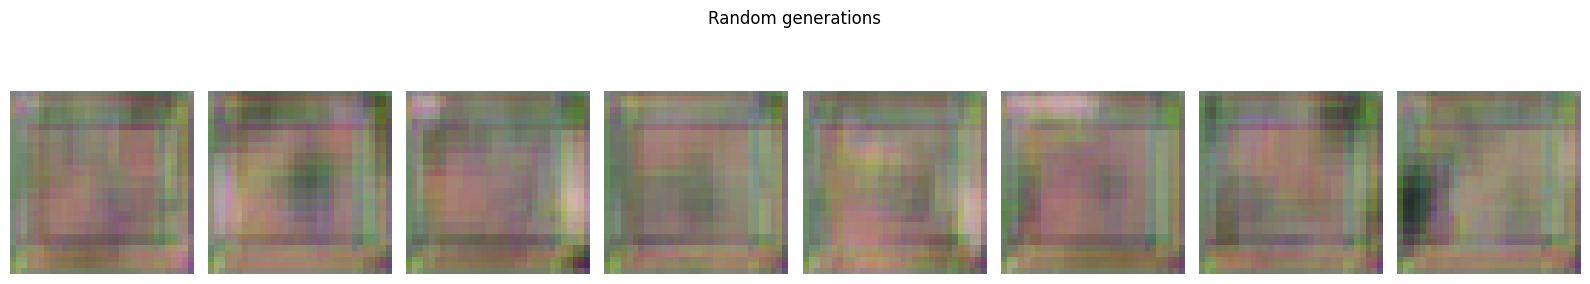

In [19]:
# ── Random Generation ─────────────────────────────────────────────────────────
model.eval()

with torch.no_grad():
    # Sample random codebook indices for a 4×4 latent grid
    random_indices = torch.randint(0, model.K, (8, 4, 4)).to(device)  # (B, H, W)

    # Look up codebook vectors
    B, H, W = random_indices.shape
    z_q = model.codebook(random_indices)             # (B, H, W, D)
    z_q = z_q.permute(0, 3, 1, 2).contiguous()      # (B, D, H, W)

    # Decode
    generated = model.decode(z_q).cpu()
    generated = (generated * 0.5 + 0.5).clamp(0, 1) # denormalize

# Plot
fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i in range(8):
    axes[i].imshow(generated[i].permute(1, 2, 0))
    axes[i].axis('off')

plt.suptitle("Random generations", y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# ── Codebook usage check ──────────────────────────────────────────────────────
model.eval()
all_indices = []

with torch.no_grad():
    for x in loader:
        x = x.to(device)
        z_e = model.encode(x)
        _, _, indices = model.quantize(z_e)
        all_indices.append(indices.cpu().flatten())

all_indices = torch.cat(all_indices)
used = all_indices.unique().numel()
print(f"Codebook entries used: {used} / {model.K}")
print(f"Usage: {used/model.K*100:.1f}%")

Codebook entries used: 12 / 32
Usage: 37.5%
